- Clément Reniers
- Louison Parant

# Exercice 1

## Question 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("./data/TP-20260303/Capital.xls")
print(df)

               Ville    TTH         Région
0    Aix en provence  18.94        Sud-Est
1            Ajaccio  22.06        Sud-Est
2             Amiens  17.97           Nord
3             Angers  18.86          Ouest
4             Annecy  14.97        Sud-Est
..               ...    ...            ...
95        Vénissieux  18.70        Sud-Est
96        Versailles   8.95  Ile-de-France
97  Villeneuve-d'Asq  29.96           Nord
98      Villeurbanne  19.85        Sud-Est
99   Vitry-sur-Seine  11.50  Ile-de-France

[100 rows x 3 columns]


## Question 2

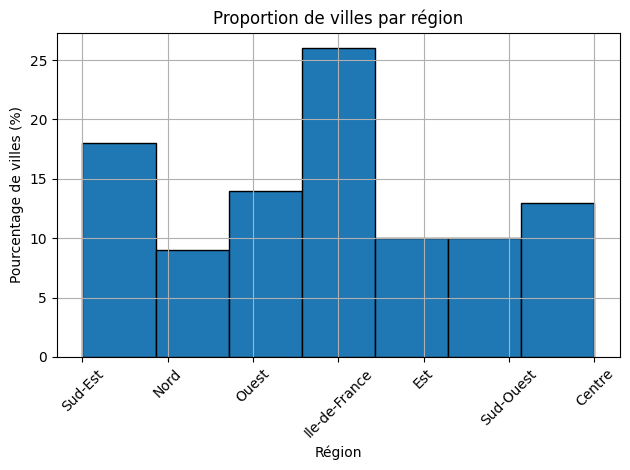

In [2]:
df['Région'].hist(bins=len(df['Région'].unique()), edgecolor='black')
plt.xlabel('Région')
plt.ylabel('Pourcentage de villes (%)')
plt.title('Proportion de villes par région')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Question 3

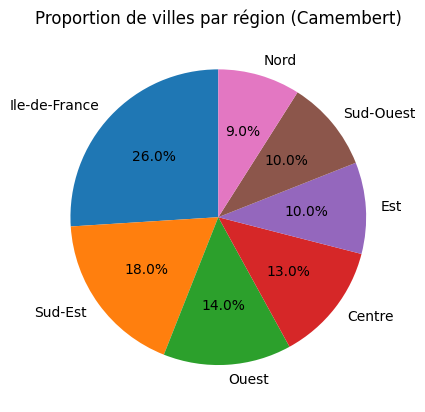

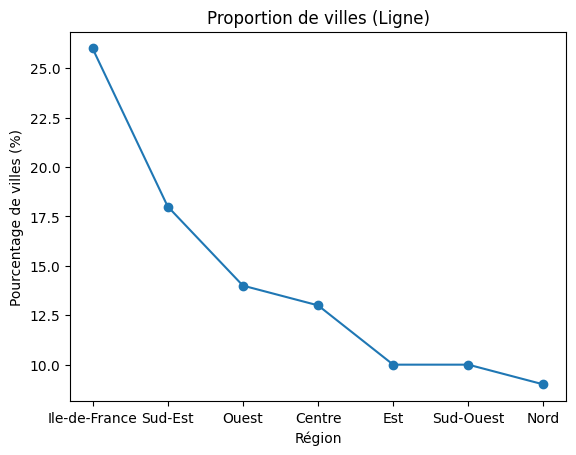

In [3]:
region_counts = df['Région'].value_counts()
region_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Proportion de villes par région (Camembert)')
plt.show()

region_counts.plot.line(marker='o')
plt.ylabel('Pourcentage de villes (%)')
plt.title('Proportion de villes (Ligne)')
plt.show()

## Question 4

In [4]:
most_cities_region = region_counts.idxmax()
print(most_cities_region)

Ile-de-France


La région la plus représentée dans ce diagramme est l'Île-de-France avec 26% des villes (soit 26 villes puisqu'il y a 100 villes au total dans le jeu de données).

## Question 5

In [5]:
tth_stats = df['TTH'].describe()
print(tth_stats)

count    100.000000
mean      17.770700
std        5.529599
min        3.680000
25%       15.062500
50%       17.625000
75%       20.522500
max       36.170000
Name: TTH, dtype: float64


In [6]:
tth_stats_by_region = df.groupby('Région')['TTH'].describe()
print(tth_stats_by_region)

               count       mean       std    min      25%     50%      75%  \
Région                                                                       
Centre          13.0  18.115385  1.906881  15.77  17.0700  17.370  19.1900   
Est             10.0  17.662000  2.095200  14.98  16.3875  16.975  18.1850   
Ile-de-France   26.0  11.764615  3.879327   3.68   9.2425  11.285  14.7375   
Nord             9.0  25.951111  7.099798  15.37  20.4600  27.970  29.9600   
Ouest           14.0  18.896429  3.098314  14.00  16.6875  18.265  21.0900   
Sud-Est         18.0  19.769444  2.938534  14.30  18.7675  19.575  21.4225   
Sud-Ouest       10.0  20.511000  4.549406  12.72  19.2700  21.010  21.9325   

                 max  
Région                
Centre         21.55  
Est            22.04  
Ile-de-France  19.32  
Nord           36.17  
Ouest          25.99  
Sud-Est        25.98  
Sud-Ouest      30.23  


## Question 6

In [7]:
print(tth_stats_by_region.idxmin().loc['mean'])

Ile-de-France


La région la plus intéressante pour le taux de taxe d'habitation avec 11.764615 de taux moyen.

## Question 7

In [8]:
national_mean = tth_stats["mean"]
abs_min = (national_mean - tth_stats_by_region["mean"]).abs().idxmin()
print(abs_min)

Est


La région la plus représentative de la moyenne nationnale (17.7707) est l'Est avec 17.662 de moyenne de taux de taxe d'habitation.

## Question 8

In [9]:
df["TTH_group"] = pd.qcut(df["TTH"], q=3, labels=["Faible", "Moyen", "Élevé"])
print(df[["Ville", "TTH", "TTH_group"]])

               Ville    TTH TTH_group
0    Aix en provence  18.94     Moyen
1            Ajaccio  22.06     Élevé
2             Amiens  17.97     Moyen
3             Angers  18.86     Moyen
4             Annecy  14.97    Faible
..               ...    ...       ...
95        Vénissieux  18.70     Moyen
96        Versailles   8.95    Faible
97  Villeneuve-d'Asq  29.96     Élevé
98      Villeurbanne  19.85     Élevé
99   Vitry-sur-Seine  11.50    Faible

[100 rows x 3 columns]


## Question 9

In [10]:
def get_deviant_cities(dataframe, mean, threshold):
    """
    Retourne les villes dont le TTH n'est pas dans l'intervalle de [-threshold, +threshold] autour de la moyenne nationale.
    dataframe: DataFrame contenant les données des villes
    mean: moyenne nationale du TTH
    threshold: seuil de déviation (ex: 0.2 pour 20%)
    """
    return dataframe[(dataframe['TTH'] > (1 + threshold) * mean) | (dataframe['TTH'] < (1 - threshold) * mean)]['Ville']

print(get_deviant_cities(df, national_mean, 0.3))

6                   Antony
8                    Arles
9       Asnières-sur-Seine
19    Boulogne-Billancourt
21                   Brest
24                  Calais
35              Courbevoie
38                  Drancy
39               Dunkerque
41      Fontenay-sous-Bois
43          Ivry-sur-Seine
45        La Seyne-sur-Mer
49                   Lille
53          Maisons-Alfort
62                Nanterre
64       Neuilly-sur-Seine
66                   Nimes
70                   Paris
78                 Roubaix
81             Saint-Denis
83      St-Maur-des-Fossés
87            Sartrouville
91               Tourcoing
96              Versailles
97        Villeneuve-d'Asq
99         Vitry-sur-Seine
Name: Ville, dtype: str


## Question 10

In [11]:
print(get_deviant_cities(df, national_mean, 0.2))

1                  Ajaccio
6                   Antony
8                    Arles
9       Asnières-sur-Seine
10           Aubervilliers
12                 Avignon
16                 Béziers
18                Bordeaux
19    Boulogne-Billancourt
21                   Brest
24                  Calais
31                  Cholet
34                Colombes
35              Courbevoie
38                  Drancy
39               Dunkerque
41      Fontenay-sous-Bois
43          Ivry-sur-Seine
45        La Seyne-sur-Mer
49                   Lille
53          Maisons-Alfort
54               Marseille
57               Montauban
58             Montpellier
59               Montreuil
62                Nanterre
64       Neuilly-sur-Seine
66                   Nimes
70                   Paris
74                Poitiers
77                  Rennes
78                 Roubaix
81             Saint-Denis
83      St-Maur-des-Fossés
87            Sartrouville
88              Strasbourg
91               Tourcoing
9

# Exercice 2

    Birth  Death  InfantDeath            Country Continent
0    24.7    5.7         30.8            Albania    Europe
1    12.5   11.9         14.4           Bulgaria    Europe
2    13.4   11.7         11.3     Czechoslovakia    Europe
3    12.0   12.4          7.6  Former_E._Germany    Europe
4    11.6   13.4         14.8            Hungary    Europe
..    ...    ...          ...                ...       ...
92   52.2   15.6        103.0             Uganda    Africa
93   50.5   14.0        106.0           Tanzania    Africa
94   45.6   14.2         83.0              Zaire    Africa
95   51.1   13.7         80.0             Zambia    Africa
96   41.7   10.3         66.0           Zimbabwe    Africa

[97 rows x 5 columns]


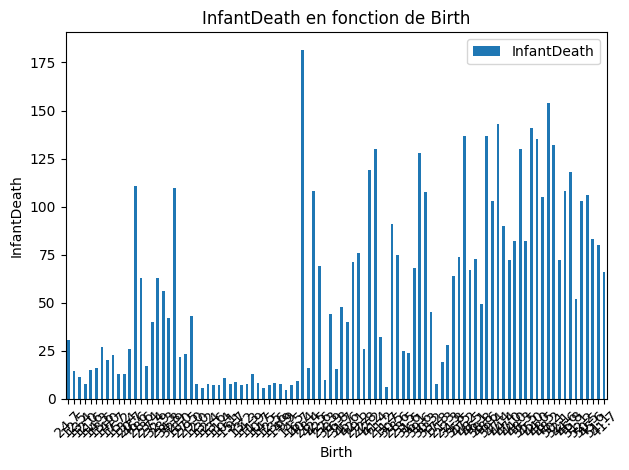

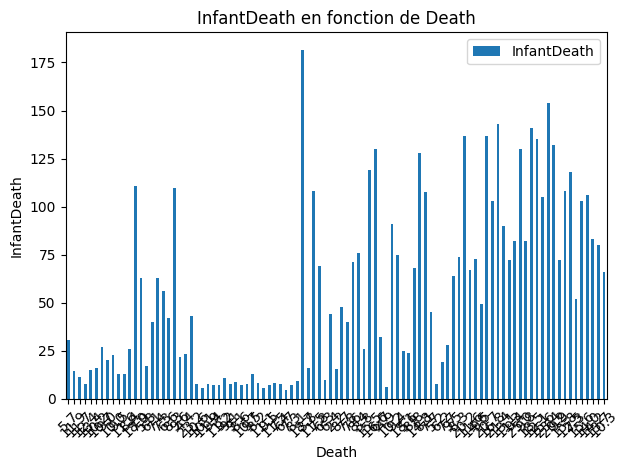

In [12]:
df2 = pd.read_csv("./data/TP-20260303/poverty.txt", delimiter='\t', header=None)
df2 = df2.rename(columns={0: "Birth", 1: "Death", 2: "InfantDeath", 3: "Country", 4: "Continent"})
print(df2)

def plot_diagram(dataframe, x, y, kind='bar', rot=45):
    """
    Trace le graphe de la variable y en fonction de x.

    Paramètres :
    - dataframe : DataFrame
    - x : nom de la colonne pour l'axe X
    - y : nom de la colonne pour l'axe Y
    - kind : type de graphe ('bar', 'line', 'scatter', etc.)
    - rot : rotation des labels de l'axe X
    """
    ax = dataframe.plot(x=x, y=y, kind=kind)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} en fonction de {x}")
    plt.xticks(rotation=rot)
    plt.tight_layout()
    plt.show()

plot_diagram(df2, "Birth", "InfantDeath", kind="bar")
plot_diagram(df2, "Death", "InfantDeath", kind="bar")

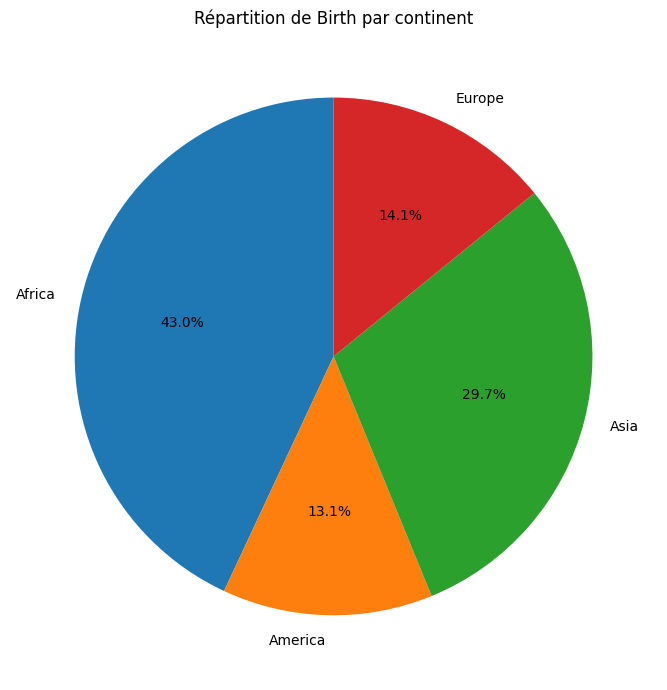

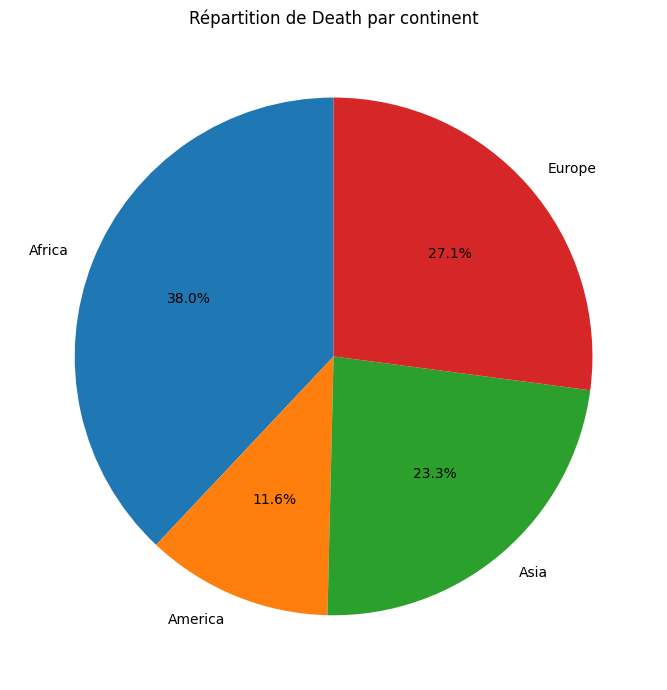

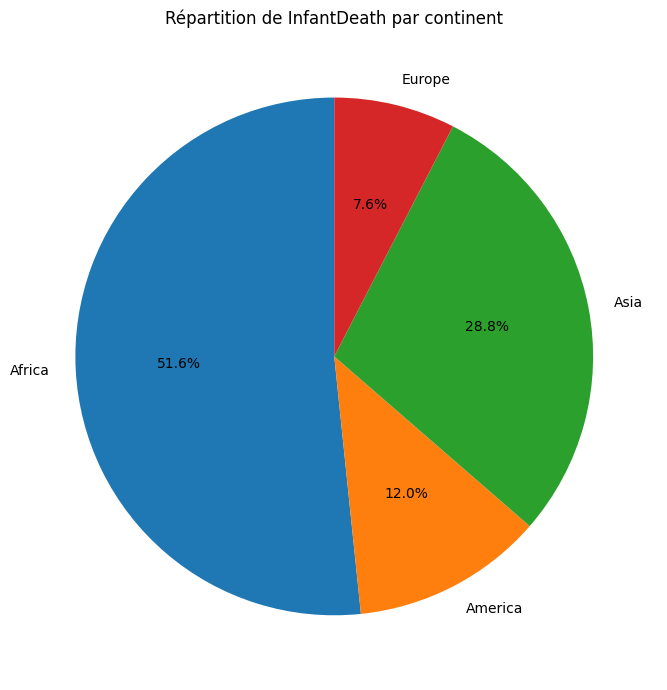

In [13]:
def plot_pie_by_continent(dataframe, variable):
    """
    Trace un camembert de la somme d'une variable (Birth, Death ou InfantDeath) par continent.

    Paramètres :
    - dataframe : DataFrame contenant les données
    - variable : nom de la colonne à agréger et afficher
    """
    continent_sums = dataframe.groupby('Continent')[variable].sum()
    ax = continent_sums.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(7, 7))
    ax.set_ylabel('')
    ax.set_title(f"Répartition de {variable} par continent")
    plt.tight_layout()
    plt.show()

plot_pie_by_continent(df2, "Birth")
plot_pie_by_continent(df2, "Death")
plot_pie_by_continent(df2, "InfantDeath")

# Exercice 3

## Question 1

In [14]:
df = pd.read_csv("./data/TP-20260303/student-mat.csv", sep=';')
print(df.columns)

def calculer_correlation(df, var1, var2):
    """
    Calcule la corrélation entre deux variables d'un DataFrame
    """
    if var1 not in df.columns or var2 not in df.columns:
        raise ValueError("Les variables doivent être des colonnes du DataFrame.")
    return abs(df[var1].corr(df[var2], method="pearson"))

Index(['Id', 'sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'activities', 'internet',
       'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
       'absences', 'Results'],
      dtype='str')


## Question 2

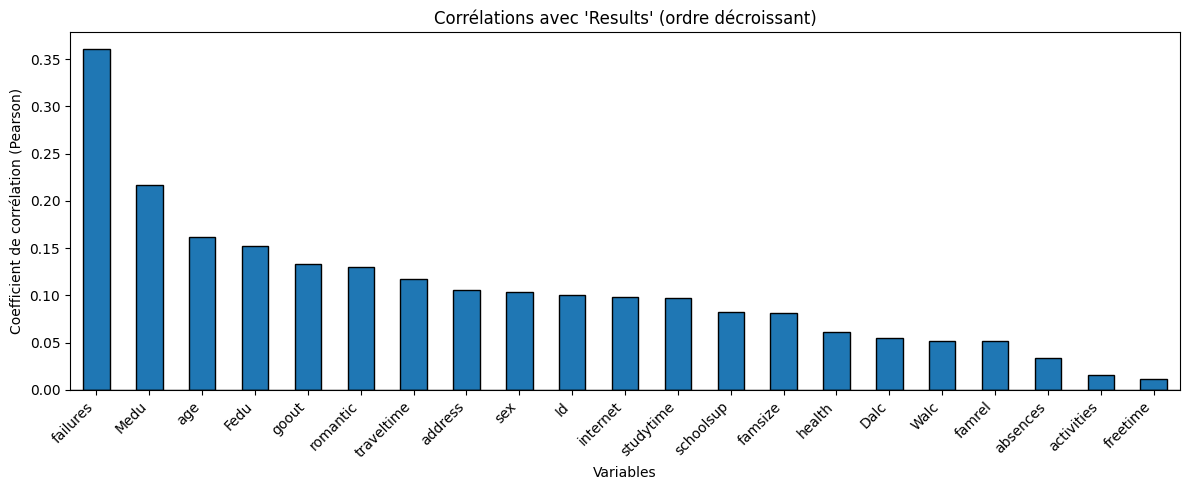

In [15]:
def plot_sorted_correlations(df, target_var):
    """
    Calcule les corrélations de toutes les variables avec une variable cible,
    les trie par ordre décroissant (|corr|), et affiche un diagramme en bâtons.
    """
    correlations = {}
    for col in df.columns:
        if col != target_var:
            correlations[col] = calculer_correlation(df, target_var, col)
    corr_series = pd.Series(dict(sorted(correlations.items(), key=lambda item: abs(item[1]), reverse=True)))

    colors = ['#1f77b4' if v >= 0 else '#d62728' for v in corr_series.values]
    ax = corr_series.plot(kind='bar', figsize=(12, 5), color=colors, edgecolor='black')

    ax.set_title(f"Corrélations avec '{target_var}' (ordre décroissant)")
    ax.set_xlabel("Variables")
    ax.set_ylabel("Coefficient de corrélation (Pearson)")
    ax.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return ax

plot_sorted_correlations(df, 'Results')
plt.show()

## Question 3

Les variables les plus corrélées sont failures, Medu et age